In [13]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../blood_data1.duckdb")


In [15]:
con.close()

In [16]:
donorrate = con.execute(""" select * from retention
                 """).df()
donorrate

,donor_id,visit_date,birth_date,previous_visit,next_visit,days_diff,visit_status,nth_visit,age
0,00000,2014-05-26,1964,2014-05-26,2015-01-25,<NA>,First Visit,1,50
1,00000,2015-01-25,1964,2014-05-26,2015-08-09,244,Returning,2,51
2,00000,2015-08-09,1964,2015-01-25,2016-03-10,196,Returning,3,51
3,00000,2016-03-10,1964,2015-08-09,2016-08-14,214,Returning,4,52
4,00000,2016-08-14,1964,2016-03-10,2016-12-19,157,Returning,5,52
...,...,...,...,...,...,...,...,...,...
6537216,09pbf,2026-01-04,1982,2026-01-04,2026-01-04,<NA>,First Visit,1,44
6537217,09pbg,2026-01-04,1984,2026-01-04,2026-01-04,<NA>,First Visit,1,42
6537218,09pbh,2026-01-04,1984,2026-01-04,2026-01-04,<NA>,First Visit,1,42
6537219,09pbi,2026-01-04,1997,2026-01-04,2026-01-04,<NA>,First Visit,1,29


In [18]:
donorrate = con.execute(""" select * from retention where visit_date = '2026-01-04'
                 """).df()
donorrate

,donor_id,visit_date,birth_date,previous_visit,next_visit,days_diff,visit_status,nth_visit,age


In [14]:
con.execute(""" delete from historical where visit_date = '2026-01-06'
                 """)

con.execute(""" delete from donorrate where latest = '2026-01-06'
                 """)

con.execute(""" delete from retention where visit_date = '2026-01-06'
                 """)


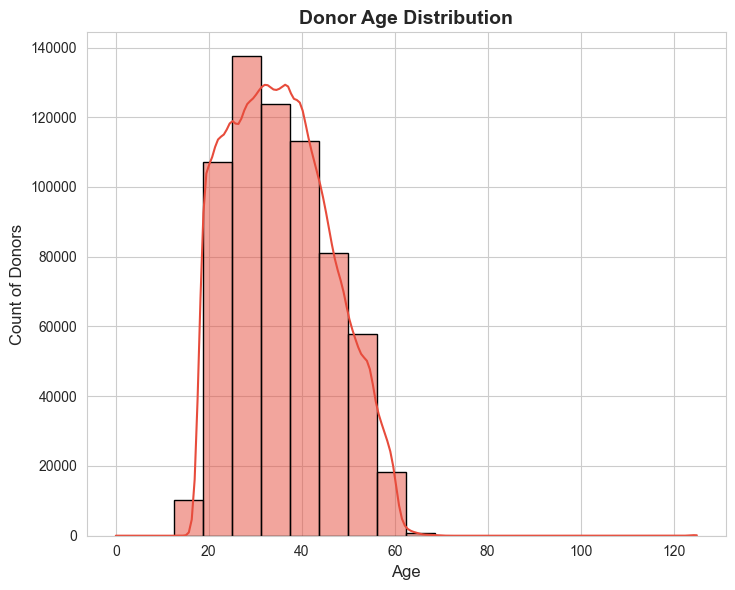

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Assuming 'donorrate' is the dataframe from your second image
# We ensure 'latest' is a datetime object
donorrate['latest'] = pd.to_datetime(donorrate['latest'])

# Set the visual style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# --- CHART 1: Age Distribution Histogram ---
# This answers: "What is the most common age of my donors?"
plt.subplot(1, 2, 1)
sns.histplot(
    data=donorrate, 
    x='age', 
    kde=True,          # Adds the smooth density curve
    bins=20,           # Groups age into ~20 buckets
    color='#e74c3c',   # Blood red color
    edgecolor='black'
)
plt.title('Donor Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count of Donors', fontsize=12)


plt.tight_layout()
plt.show()

In [ ]:

year = 2013

# df = con.execute(f"""
#     SELECT
#       donor_id,
#       CASE WHEN SUM(CASE WHEN year(visit_date) = {year} THEN 1 ELSE 0 END) > 0 THEN 1 ELSE 0 END AS t{year},
#       CASE WHEN SUM(CASE WHEN year(visit_date) >= {year + 1} THEN 1 ELSE 0 END) > 0 THEN 1 ELSE 0 ND AS t{year + 1}_plus
#     FROM retention
#     GROUP BY donor_id
#     ORDER BY donor_id;
# """).df()

list_donor_id = con.execute(""" select count(distinct donor_id) as total from (
                select * ,
                row_number() over(partition by donor_id order by visit_date) as num
                from retention
                where year(visit_date) = 2013
                order by donor_id,num)
                where num = 1
                 """).df()

list_donor_id

,total
0,347393


In [88]:
list_donor_id = con.execute(""" select * from (
                select * ,
                lead(visit_date,3) over(partition by donor_id order by visit_date) as next_visit,
                row_number() over(partition by donor_id order by visit_date) as num
                from retention
                order by donor_id,visit_date,num)
                where year(visit_date) = 2014 and
                num = 1
                

                 """).df()

list_donor_id

,donor_id,visit_date,birth_date,next_visit,num
0,0000Y,2014-04-27,1977,2017-05-28,1
1,0000g,2014-01-05,1975,2015-01-25,1
2,0000i,2014-01-05,1983,2019-08-25,1
3,0000j,2014-01-05,1970,2024-03-03,1
4,0000k,2014-01-05,1980,2020-02-02,1
...,...,...,...,...,...
262622,08czq,2014-02-18,1990,NaT,1
262623,08czs,2014-03-15,1975,NaT,1
262624,08czu,2014-12-13,1979,NaT,1
262625,08czx,2014-04-30,1991,NaT,1


#### To calculate rentention from what year to what year

In [122]:
year = con.execute(f"""  select min(year(visit_date)) ,max(year(visit_date)) from retention 
                    """).fetchall()
year[0][1]


2025

In [ ]:

start_year = year[0][0]
end_year = year[0][1]
year_dict = {}


for i in range(0,end_year - start_year + 1):
    parent_year = start_year + i
    if parent_year == end_year:
        break
    else:
        year_dict[parent_year] = {}
        for j in range(1,end_year - parent_year + 1):
            
            child_year = parent_year + j
            total = con.execute(f"""  select count(*) from (
                                select donor_id ,year(visit_date) as yearr,count(*),
                                lead(yearr,{j}) over(partition by donor_id order by yearr) as next_year,
                                row_number() over(partition by donor_id order by yearr) as num
                                from retention group by donor_id,yearr)
                                where num = 1
                                and yearr = {parent_year}
                                and next_year = {child_year}
                                
                                """).fetchone()[0]

            year_dict[parent_year][child_year] = total


{2013: {2014: 123545, 2015: 68360, 2016: 44404, 2017: 31297, 2018: 24175, 2019: 18803, 2020: 12875, 2021: 10060, 2022: 8621, 2023: 7468, 2024: 6544, 2025: 5673}, 2014: {2015: 73109, 2016: 33623, 2017: 19129, 2018: 12771, 2019: 9042, 2020: 5925, 2021: 4426, 2022: 3663, 2023: 3090, 2024: 2641, 2025: 2222}, 2015: {2016: 58458, 2017: 24429, 2018: 13406, 2019: 8384, 2020: 4850, 2021: 3398, 2022: 2687, 2023: 2212, 2024: 1858, 2025: 1522}, 2016: {2017: 47430, 2018: 20022, 2019: 10318, 2020: 5282, 2021: 3417, 2022: 2548, 2023: 2020, 2024: 1618, 2025: 1325}, 2017: {2018: 43587, 2019: 17591, 2020: 7488, 2021: 4414, 2022: 3132, 2023: 2363, 2024: 1868, 2025: 1497}, 2018: {2019: 42166, 2020: 13482, 2021: 7057, 2022: 4739, 2023: 3413, 2024: 2620, 2025: 2036}, 2019: {2020: 34483, 2021: 15071, 2022: 8976, 2023: 6074, 2024: 4534, 2025: 3479}, 2020: {2021: 34294, 2022: 15843, 2023: 9165, 2024: 6084, 2025: 4330}, 2021: {2022: 28755, 2023: 13055, 2024: 7551, 2025: 5001}, 2022: {2023: 33931, 2024: 15240, 2

In [127]:
year_dict[2013]

{2014: 123545,
 2015: 68360,
 2016: 44404,
 2017: 31297,
 2018: 24175,
 2019: 18803,
 2020: 12875,
 2021: 10060,
 2022: 8621,
 2023: 7468,
 2024: 6544,
 2025: 5673}

In [126]:
total = con.execute(f"""  select year ,count(year) from (
                    select donor_id ,year(visit_date) as year,count(*),
                    row_number() over(partition by donor_id order by year) as num
                    from retention group by donor_id,year)
                    where num = 1
                    group by year order by year
                    """).fetchall()

total_new_donor = dict(total)
total_new_donor

{2013: 347393,
 2014: 262627,
 2015: 239053,
 2016: 208499,
 2017: 186935,
 2018: 189343,
 2019: 178984,
 2020: 132987,
 2021: 109425,
 2022: 133417,
 2023: 129318,
 2024: 123616,
 2025: 105423}

In [133]:
rate_retention = {}

for i in range(end_year-start_year + 1):
    parent_year = start_year + i
    rate_retention[parent_year] = {}
    for j in range(1,end_year - parent_year + 1):
        child_year = parent_year + j
        rate = (year_dict[parent_year][child_year] / total_new_donor[parent_year]) * 100
        rate_retention[parent_year][child_year] = round(rate,2)

rate_retention

{2013: {2014: 35.56,
  2015: 19.68,
  2016: 12.78,
  2017: 9.01,
  2018: 6.96,
  2019: 5.41,
  2020: 3.71,
  2021: 2.9,
  2022: 2.48,
  2023: 2.15,
  2024: 1.88,
  2025: 1.63},
 2014: {2015: 27.84,
  2016: 12.8,
  2017: 7.28,
  2018: 4.86,
  2019: 3.44,
  2020: 2.26,
  2021: 1.69,
  2022: 1.39,
  2023: 1.18,
  2024: 1.01,
  2025: 0.85},
 2015: {2016: 24.45,
  2017: 10.22,
  2018: 5.61,
  2019: 3.51,
  2020: 2.03,
  2021: 1.42,
  2022: 1.12,
  2023: 0.93,
  2024: 0.78,
  2025: 0.64},
 2016: {2017: 22.75,
  2018: 9.6,
  2019: 4.95,
  2020: 2.53,
  2021: 1.64,
  2022: 1.22,
  2023: 0.97,
  2024: 0.78,
  2025: 0.64},
 2017: {2018: 23.32,
  2019: 9.41,
  2020: 4.01,
  2021: 2.36,
  2022: 1.68,
  2023: 1.26,
  2024: 1.0,
  2025: 0.8},
 2018: {2019: 22.27,
  2020: 7.12,
  2021: 3.73,
  2022: 2.5,
  2023: 1.8,
  2024: 1.38,
  2025: 1.08},
 2019: {2020: 19.27,
  2021: 8.42,
  2022: 5.01,
  2023: 3.39,
  2024: 2.53,
  2025: 1.94},
 2020: {2021: 25.79, 2022: 11.91, 2023: 6.89, 2024: 4.57, 2025: 3

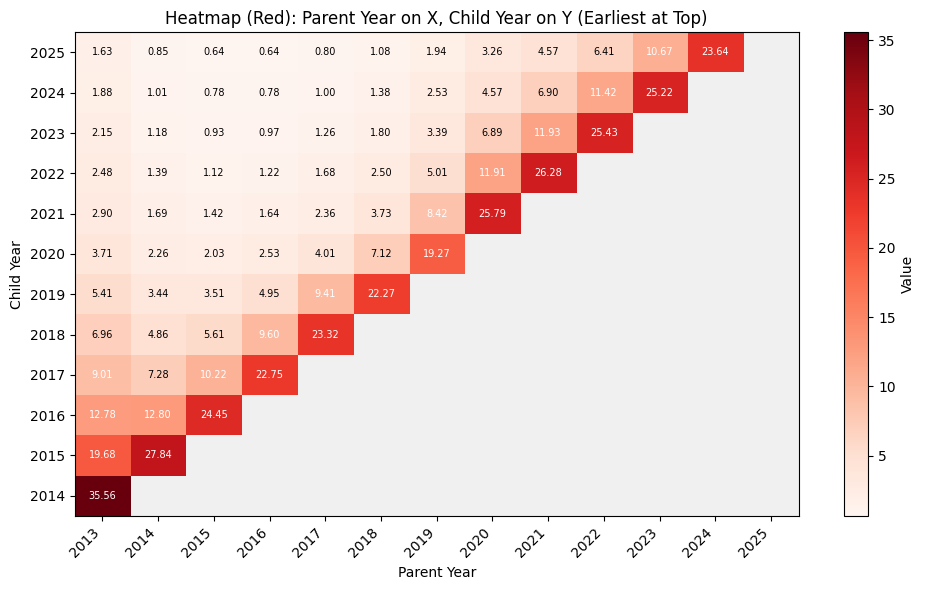

In [152]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = rate_retention  # <- your nested dict: {parent_year: {child_year: value, ...}}

# Build matrix: rows=parent, cols=child
rows = sorted(data.keys())  # parent years
cols = sorted({child for inner in data.values() for child in inner.keys()})  # child years
mat = pd.DataFrame(index=rows, columns=cols, dtype=float)
for parent, children in data.items():
    for child, val in children.items():
        mat.loc[parent, child] = val

# Parent → X, Child → Y
mat_for_plot = mat.T  # rows=child (Y), cols=parent (X)

# Ensure child years (rows) are ascending (earliest at top)
mat_for_plot = mat_for_plot.reindex(sorted(mat_for_plot.index))          # Y-axis order
mat_for_plot = mat_for_plot.reindex(sorted(mat_for_plot.columns), axis=1) # X-axis order

fig, ax = plt.subplots(figsize=(10, 6))
masked = np.ma.masked_invalid(mat_for_plot.values)

# Monochrome red colormap
cmap = plt.cm.Reds
cmap.set_bad(color='#f0f0f0')  # light gray for NaNs

im = ax.imshow(masked, aspect='auto', cmap=cmap, interpolation='nearest')
ax.invert_yaxis()

# Axis labels and ticks
ax.set_xticks(range(len(mat_for_plot.columns)))
ax.set_xticklabels(mat_for_plot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(mat_for_plot.index)))
ax.set_yticklabels(mat_for_plot.index)
ax.set_xlabel('Parent Year')
ax.set_ylabel('Child Year')
ax.set_title('Heatmap (Red): Parent Year on X, Child Year on Y (Earliest at Top)')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Value')

# Optional annotations
for i in range(len(mat_for_plot.index)):
    for j in range(len(mat_for_plot.columns)):
        val = mat_for_plot.iat[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.2f}", va='center', ha='center', fontsize=7,
                    color='white' if masked[i, j] > masked.mean() else 'black')

plt.tight_layout()
plt.show()


In [150]:
total = con.execute(f"""  select * from (
                                select donor_id ,year(visit_date) as yearr,count(*),
                                lead(yearr,3) over(partition by donor_id order by yearr) as next_year,
                                row_number() over(partition by donor_id order by yearr) as num
                                from retention 
                                where donor_id = '039Kq'
                                group by donor_id,yearr)

                                
                    
                                
                                """).df()
total

,donor_id,yearr,count_star(),next_year,num
0,039Kq,2013,4,2016,1
1,039Kq,2014,4,2017,2
2,039Kq,2015,4,2018,3
3,039Kq,2016,4,2019,4
4,039Kq,2017,4,2020,5
5,039Kq,2018,4,2021,6
6,039Kq,2019,4,2022,7
7,039Kq,2020,4,2023,8
8,039Kq,2021,4,2024,9
9,039Kq,2022,3,2025,10


In [146]:
total = con.execute(f"""  
                                select donor_id ,year(visit_date) as yearr,count(*),
                                lead(yearr,12) over(partition by donor_id order by yearr) as next_year,
                                row_number() over(partition by donor_id order by yearr) as num
                                from retention group by donor_id,yearr
                                
                                """).df()
total

,donor_id,yearr,count_star(),next_year,num
0,0000T,2013,1,<NA>,1
1,0000T,2014,1,<NA>,2
2,0000T,2015,1,<NA>,3
3,0000T,2018,1,<NA>,4
4,0000T,2020,3,<NA>,5
...,...,...,...,...,...
5189925,010uU,2025,1,<NA>,2
5189926,010vU,2020,1,<NA>,1
5189927,010xB,2020,1,<NA>,1
5189928,010xB,2021,1,<NA>,2


In [143]:
total = con.execute(f"""  select count(*) from (
                                select donor_id ,year(visit_date) as yearr,count(*),
                                row_number() over(partition by donor_id order by yearr) as num
                                from retention group by donor_id,yearr)
                                where num = 1
                                and yearr = 2013
                               
                                
                                """).fetchone()[0]
total

347393

In [ ]:
df = con.execute(""" select donor_id, count(donor_id) as total from (
                 select donor_id ,birth_date, count(birth_date) as total from retention group by donor_id, birth_date  order by total desc)
                 group by donor_id
                 having total > 1
                 """).df()

df

In [25]:
df = con.execute(""" select distinct year(visit_date)  as year from retention order by year
                 """).df()

df

,year
0,2013
1,2014
2,2015
3,2016
4,2017
5,2018
6,2019
7,2020
8,2021
9,2022


In [3]:
con.close()